# Análise de incidentes de segurança com Python

## Objetivo

Analisar padrões presentes em registros públicos de incidentes de segurança, utilizando dados estruturados segundo o framework VERIS.

## Fonte de dados

VERIS Community Database (VCDB).

O Verizon DBIR 2026 é utilizado como referência metodológica e contextual. O conjunto completo dos registros utilizado no DBIR não é disponibilizado publicamente, portanto, esta análise utiliza o VCDB como fonte pública de dados.

## Pergunta da análise

Quais padrões de ocorrência e características dos incidentes de segurança podem ser observados nos registros analisados?

## Tecnologias

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

# 1. Configuração

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carregamento dos dados

## 2.1 Definição das colunas utilizadas

In [2]:
colunas_acoes = [
    "action.Hacking",
    "action.Malware",
    "action.Social",
    "action.Physical",
    "action.Misuse",
    "action.Error",
    "action.Environmental",
    "action.Unknown"
]

In [3]:
colunas_disponiveis = pd.read_csv(
    "../data/raw/vcdb.csv",
    nrows=0
).columns

In [4]:
colunas_hacking = [
    col for col in colunas_disponiveis
    if col.startswith("action.hacking.variety.")
]

colunas_vetores_hacking = [
    col for col in colunas_disponiveis
    if col.startswith("action.hacking.vector.")
]

colunas_vetores_malware = [
    col for col in colunas_disponiveis
    if col.startswith("action.malware.vector.")
]

colunas_vetores_social = [
    col for col in colunas_disponiveis
    if col.startswith("action.social.vector.")
]

colunas_vetores_error = [
    col for col in colunas_disponiveis
    if col.startswith("action.error.vector.")
]

colunas_vetores_physical = [
    col for col in colunas_disponiveis
    if col.startswith("action.physical.vector.")
]

colunas_vitimas_dados = [
    col for col in colunas_disponiveis
    if col.startswith("attribute.confidentiality.data_victim.")
]

In [5]:
colunas_projeto = (
    [
        "timeline.incident.year",
        "victim.industry.name"
    ]
    + colunas_acoes
    + colunas_hacking
    + colunas_vetores_hacking
    + colunas_vetores_malware
    + colunas_vetores_social
    + colunas_vetores_error
    + colunas_vetores_physical
    + colunas_vitimas_dados
)

In [6]:
dados = pd.read_csv(
    "../data/raw/vcdb.csv",
    usecols=colunas_projeto
)

In [7]:
dados.shape

(10596, 142)

# 3. Preparação e limpeza dos dados

In [8]:
dados["victim.industry.name"] = (
    dados["victim.industry.name"].str.strip()
)

In [9]:
dados[
    ["timeline.incident.year", "victim.industry.name"]
].isna().sum()

timeline.incident.year    0
victim.industry.name      0
dtype: int64

In [10]:
print(
    "Anos como Unknown:",
    (dados["timeline.incident.year"] == "Unknown").sum()
)

print(
    "Setores como Unknown:",
    (dados["victim.industry.name"] == "Unknown").sum()
)

Anos como Unknown: 0
Setores como Unknown: 231


# 4. Análise final

## 4.1 Perfil geral dos incidentes

In [11]:
total_incidentes = len(dados)

print(f"Total de incidentes analisados: {total_incidentes:,}".replace(",", "."))

Total de incidentes analisados: 10.596


## 4.2 Setores dos incidentes

In [12]:
frequencia_setores = (
    dados["victim.industry.name"]
    .value_counts()
)

frequencia_setores

victim.industry.name
Healthcare        2564
Public            2403
Educational       1155
Finance            980
Information        876
Retail             529
Professional       488
Manufacturing      271
Unknown            231
Other Services     218
Administrative     196
Accomodation       173
Transportation     141
Trade              100
Entertainment       91
Real Estate         55
Utilities           47
Construction        32
Mining              26
Management          15
Agriculture          5
Name: count, dtype: int64

In [13]:
percentual_setores = (
    dados["victim.industry.name"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

percentual_setores

victim.industry.name
Healthcare        24.2
Public            22.7
Educational       10.9
Finance            9.2
Information        8.3
Retail             5.0
Professional       4.6
Manufacturing      2.6
Unknown            2.2
Other Services     2.1
Administrative     1.8
Accomodation       1.6
Transportation     1.3
Trade              0.9
Entertainment      0.9
Real Estate        0.5
Utilities          0.4
Construction       0.3
Mining             0.2
Management         0.1
Agriculture        0.0
Name: proportion, dtype: float64

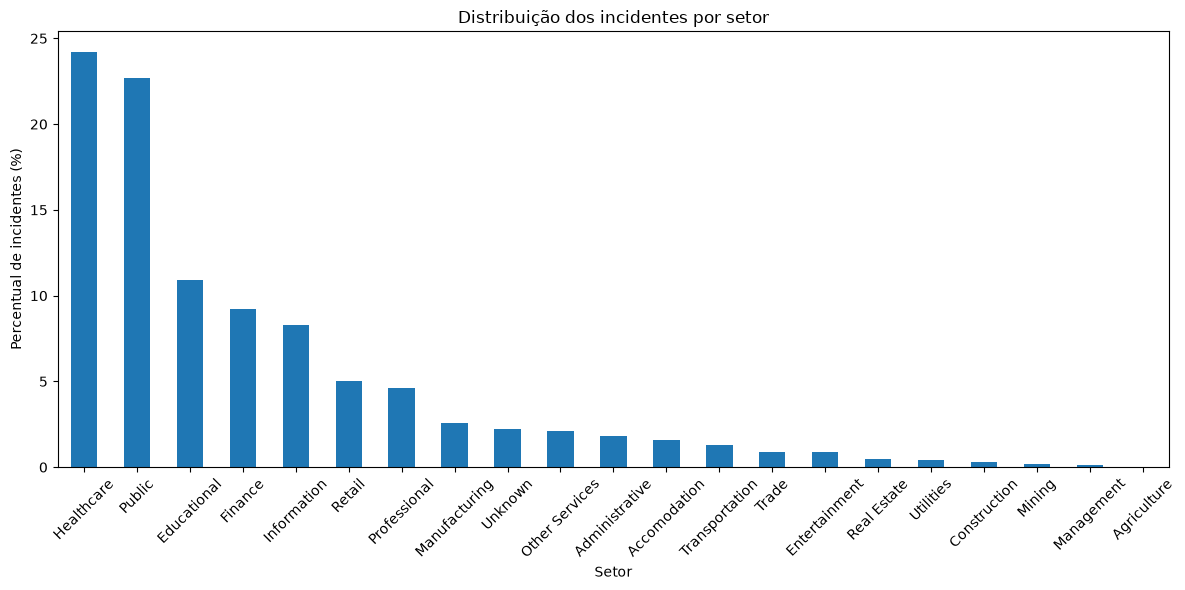

In [14]:
percentual_setores.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribuição dos incidentes por setor")
plt.xlabel("Setor")
plt.ylabel("Percentual de incidentes (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
setores_principais = (
    dados["victim.industry.name"]
    .value_counts()
    .head(7)
    .index
    .tolist()
)

setores_principais

['Healthcare',
 'Public',
 'Educational',
 'Finance',
 'Information',
 'Retail',
 'Professional']

## 4.3 Categorias de ação por setor

In [16]:
proporcoes_acoes_setor = (
    dados
    .groupby("victim.industry.name")[colunas_acoes]
    .mean()
    .mul(100)
    .round(1)
)

In [17]:
proporcoes_principais = (
    proporcoes_acoes_setor
    .loc[setores_principais]
)

proporcoes_principais

,action.Hacking,action.Malware,action.Social,action.Physical,action.Misuse,action.Error,action.Environmental,action.Unknown
victim.industry.name,,,,,,,,
Healthcare,14.0,8.9,5.7,27.2,25.2,26.7,0.1,3.9
Public,21.5,9.6,8.1,7.7,21.6,46.5,0.1,2.0
Educational,70.2,59.4,4.2,6.5,4.2,13.2,0.0,2.7
Finance,31.3,13.5,5.3,27.6,13.4,21.4,0.0,5.4
Information,65.8,9.7,6.1,1.9,7.8,19.3,0.5,4.3
Retail,30.8,11.5,3.2,39.7,10.2,12.1,0.0,4.2
Professional,47.3,18.4,7.0,7.4,13.5,23.0,0.0,4.1


In [18]:
nomes_acoes = {
    "action.Hacking": "Hacking",
    "action.Malware": "Malware",
    "action.Social": "Social",
    "action.Physical": "Physical",
    "action.Misuse": "Misuse",
    "action.Error": "Error",
    "action.Environmental": "Environmental",
    "action.Unknown": "Unknown"
}

proporcoes_principais = (
    proporcoes_principais
    .rename(columns=nomes_acoes)
)

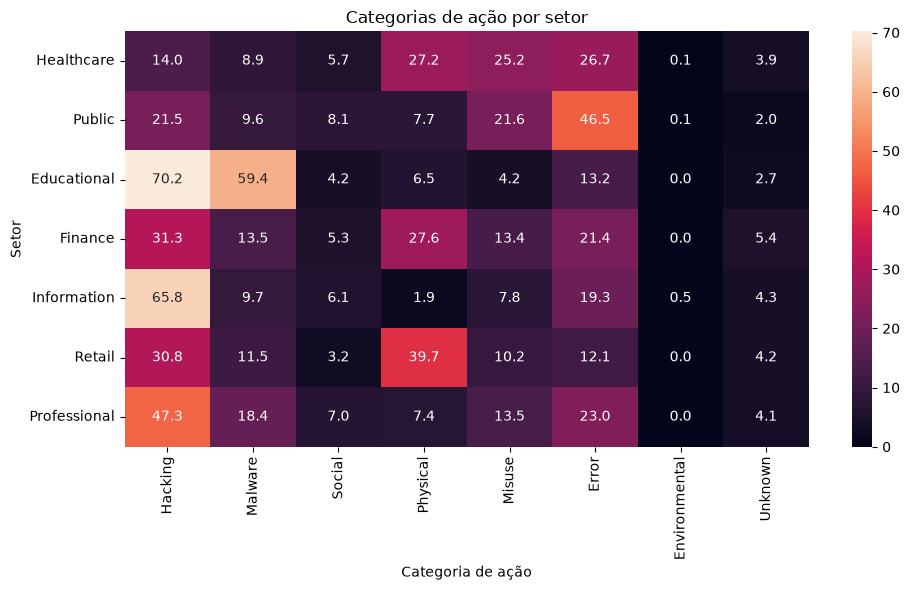

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    proporcoes_principais,
    annot=True,
    fmt=".1f"
)

plt.title("Categorias de ação por setor")
plt.xlabel("Categoria de ação")
plt.ylabel("Setor")

plt.tight_layout()
plt.show()

## 4.4 Hacking - principais vetores por setor

In [20]:
dados_hacking = dados[
    dados["action.Hacking"] == True
]

In [21]:
len(dados_hacking)

3635

In [22]:
contagem_vetores_hacking = (
    dados_hacking[colunas_vetores_hacking]
    .sum()
    .sort_values(ascending=False)
)

contagem_vetores_hacking

action.hacking.vector.Web application             2202
action.hacking.vector.Unknown                     1103
action.hacking.vector.Backdoor                     222
action.hacking.vector.Other                         40
action.hacking.vector.Partner                       31
action.hacking.vector.Physical access               18
action.hacking.vector.Desktop sharing software      17
action.hacking.vector.VPN                           13
action.hacking.vector.Desktop sharing               13
action.hacking.vector.Command shell                 11
action.hacking.vector.Other network service          8
action.hacking.vector.3rd party desktop              3
action.hacking.vector.Inter-tenant                   2
action.hacking.vector.Hypervisor                     0
dtype: int64

In [23]:
tabela_vetores_hacking = (
    contagem_vetores_hacking[
        ~contagem_vetores_hacking.index.str.endswith(".Unknown")
    ]
)

top_vetores_hacking = (
    tabela_vetores_hacking
    .head(5)
)

top_vetores_hacking

action.hacking.vector.Web application    2202
action.hacking.vector.Backdoor            222
action.hacking.vector.Other                40
action.hacking.vector.Partner              31
action.hacking.vector.Physical access      18
dtype: int64

In [24]:
colunas_top_vetores_hacking = (
    top_vetores_hacking.index.tolist()
)

tabela_vetores_setor = (
    dados_hacking
    .groupby("victim.industry.name")[colunas_top_vetores_hacking]
    .mean()
    .mul(100)
    .round(1)
)

In [25]:
tabela_principais_hacking = (
    tabela_vetores_setor
    .loc[setores_principais]
)

tabela_principais_hacking

,action.hacking.vector.Web application,action.hacking.vector.Backdoor,action.hacking.vector.Other,action.hacking.vector.Partner,action.hacking.vector.Physical access
victim.industry.name,,,,,
Healthcare,35.1,1.7,1.9,1.7,0.8
Public,45.0,25.4,1.0,0.2,0.8
Educational,86.2,0.2,0.5,0.1,0.2
Finance,65.8,2.0,0.3,2.0,0.7
Information,63.5,2.4,1.0,1.2,0.3
Retail,64.4,1.2,1.2,1.8,0.0
Professional,52.4,7.8,3.0,1.7,0.0


In [26]:
nomes_vetores_hacking = {
    "action.hacking.vector.Web application": "Web application",
    "action.hacking.vector.Backdoor": "Backdoor",
    "action.hacking.vector.Other": "Other",
    "action.hacking.vector.Partner": "Partner",
    "action.hacking.vector.Physical access": "Physical access"
}

tabela_principais_hacking = (
    tabela_principais_hacking
    .rename(columns=nomes_vetores_hacking)
)

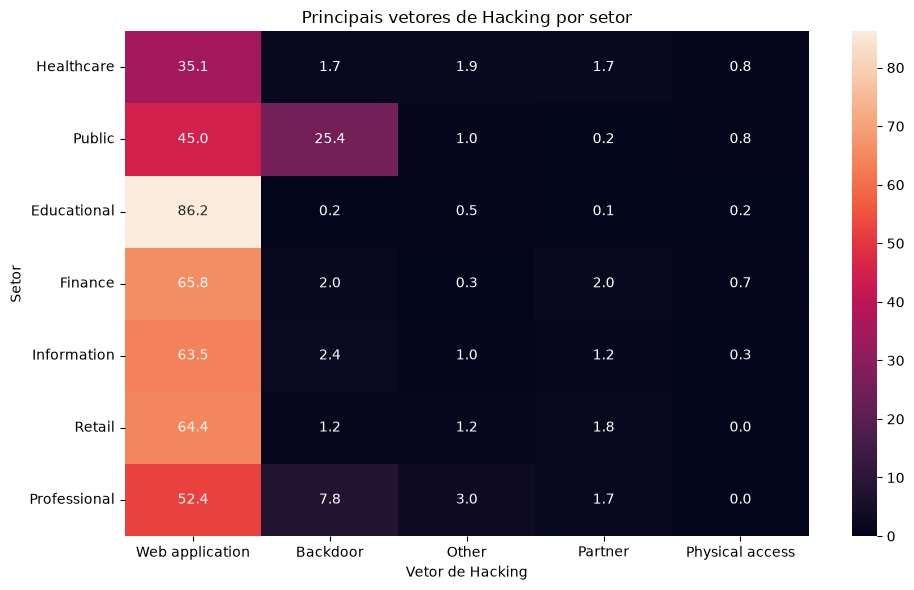

In [27]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabela_principais_hacking,
    annot=True,
    fmt=".1f"
)

plt.title("Principais vetores de Hacking por setor")
plt.xlabel("Vetor de Hacking")
plt.ylabel("Setor")

plt.tight_layout()
plt.show()

## 4.5 Malware — principais vetores por setor

In [28]:
dados_malware = dados[
    dados["action.Malware"] == True
]

len(dados_malware)

1774

In [29]:
contagem_vetores_malware = (
    dados_malware[colunas_vetores_malware]
    .sum()
    .sort_values(ascending=False)
)

contagem_vetores_malware

action.malware.vector.Direct install                906
action.malware.vector.Remote injection              747
action.malware.vector.Unknown                       568
action.malware.vector.Email attachment              224
action.malware.vector.Web application                30
action.malware.vector.Web application - drive-by     26
action.malware.vector.Download by malware            12
action.malware.vector.Email link                     10
action.malware.vector.Web application - download      9
action.malware.vector.Removable media                 4
action.malware.vector.Email unknown                   4
action.malware.vector.Email autoexecute               4
action.malware.vector.Software update                 4
action.malware.vector.Other                           3
action.malware.vector.Network propagation             3
action.malware.vector.Email                           2
action.malware.vector.Partner                         2
action.malware.vector.C2                        

In [30]:
tabela_vetores_malware = (
    contagem_vetores_malware[
        ~contagem_vetores_malware.index.str.endswith(".Unknown")
    ]
)

top_vetores_malware = (
    tabela_vetores_malware
    .head(5)
)

top_vetores_malware

action.malware.vector.Direct install                906
action.malware.vector.Remote injection              747
action.malware.vector.Email attachment              224
action.malware.vector.Web application                30
action.malware.vector.Web application - drive-by     26
dtype: int64

In [31]:
colunas_top_vetores_malware = (
    top_vetores_malware.index.tolist()
)

tabela_vetores_setor_malware = (
    dados_malware
    .groupby("victim.industry.name")[colunas_top_vetores_malware]
    .mean()
    .mul(100)
    .round(1)
)

In [32]:
tabela_principais_malware = (
    tabela_vetores_setor_malware
    .loc[setores_principais]
)

tabela_principais_malware

,action.malware.vector.Direct install,action.malware.vector.Remote injection,action.malware.vector.Email attachment,action.malware.vector.Web application,action.malware.vector.Web application - drive-by
victim.industry.name,,,,,
Healthcare,12.8,3.1,6.2,1.3,0.4
Public,10.9,3.5,60.9,1.3,0.9
Educational,90.4,89.2,0.9,0.1,0.1
Finance,72.7,59.8,3.8,0.8,0.8
Information,24.7,7.1,4.7,14.1,14.1
Retail,34.4,9.8,1.6,0.0,0.0
Professional,30.0,13.3,12.2,0.0,0.0


In [33]:
nomes_vetores_malware = {
    "action.malware.vector.Direct install": "Direct install",
    "action.malware.vector.Remote injection": "Remote injection",
    "action.malware.vector.Email attachment": "Email attachment",
    "action.malware.vector.Web application": "Web application",
    "action.malware.vector.Web application - drive-by": "Web drive-by"
}

tabela_principais_malware = (
    tabela_principais_malware
    .rename(columns=nomes_vetores_malware)
)

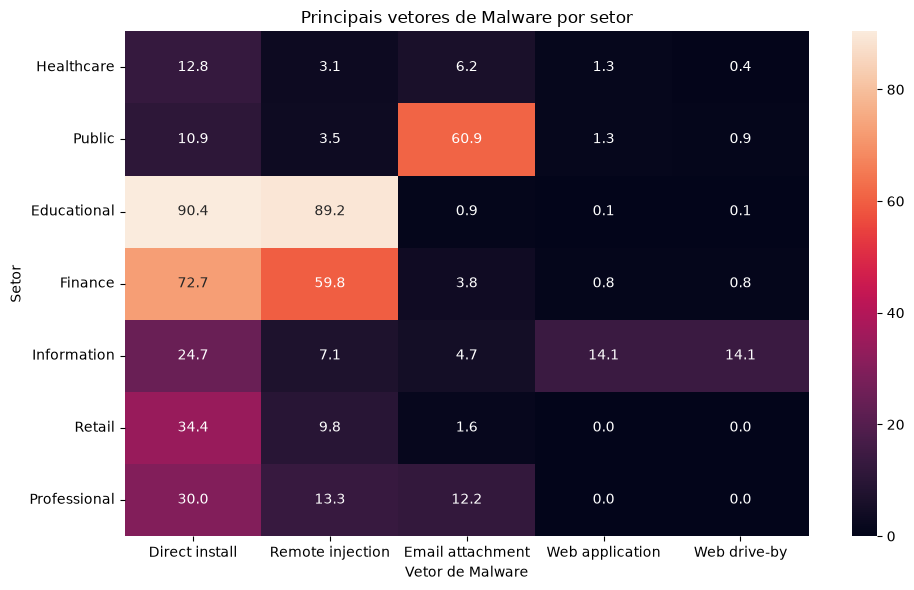

In [34]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabela_principais_malware,
    annot=True,
    fmt=".1f"
)

plt.title("Principais vetores de Malware por setor")
plt.xlabel("Vetor de Malware")
plt.ylabel("Setor")

plt.tight_layout()
plt.show()

## 4.6 Social Engineering — principais vetores por setor

In [35]:
dados_social = dados[
    dados["action.Social"] == True
]

len(dados_social)

681

In [36]:
contagem_vetores_social = (
    dados_social[colunas_vetores_social]
    .sum()
    .sort_values(ascending=False)
)

contagem_vetores_social

action.social.vector.Email              481
action.social.vector.Unknown             81
action.social.vector.In-person           55
action.social.vector.Phone               30
action.social.vector.Documents           15
action.social.vector.SMS                 15
action.social.vector.Software            12
action.social.vector.Web application      9
action.social.vector.Partner              8
action.social.vector.IM                   4
action.social.vector.Social media         4
action.social.vector.Other                3
action.social.vector.Removable media      1
action.social.vector.Virtual meeting      0
dtype: int64

In [37]:
tabela_vetores_social = (
    contagem_vetores_social[
        ~contagem_vetores_social.index.str.endswith(".Unknown")
    ]
)

top_vetores_social = (
    tabela_vetores_social
    .head(5)
)

top_vetores_social

action.social.vector.Email        481
action.social.vector.In-person     55
action.social.vector.Phone         30
action.social.vector.Documents     15
action.social.vector.SMS           15
dtype: int64

In [38]:
colunas_top_vetores_social = (
    top_vetores_social.index.tolist()
)

tabela_vetores_setor_social = (
    dados_social
    .groupby("victim.industry.name")[colunas_top_vetores_social]
    .mean()
    .mul(100)
    .round(1)
)

In [39]:
tabela_principais_social = (
    tabela_vetores_setor_social
    .loc[setores_principais]
)

tabela_principais_social

,action.social.vector.Email,action.social.vector.In-person,action.social.vector.Phone,action.social.vector.Documents,action.social.vector.SMS
victim.industry.name,,,,,
Healthcare,67.6,11.7,2.1,4.1,0.0
Public,84.5,5.2,2.1,1.5,0.0
Educational,87.8,0.0,0.0,0.0,2.0
Finance,51.9,17.3,11.5,3.8,3.8
Information,58.5,3.8,7.5,0.0,11.3
Retail,47.1,17.6,17.6,5.9,0.0
Professional,61.8,0.0,8.8,0.0,2.9


In [40]:
nomes_vetores_social = {
    "action.social.vector.Email": "Email",
    "action.social.vector.In-person": "In-person",
    "action.social.vector.Phone": "Phone",
    "action.social.vector.Documents": "Documents",
    "action.social.vector.SMS": "SMS"
}

tabela_principais_social = (
    tabela_principais_social
    .rename(columns=nomes_vetores_social)
)

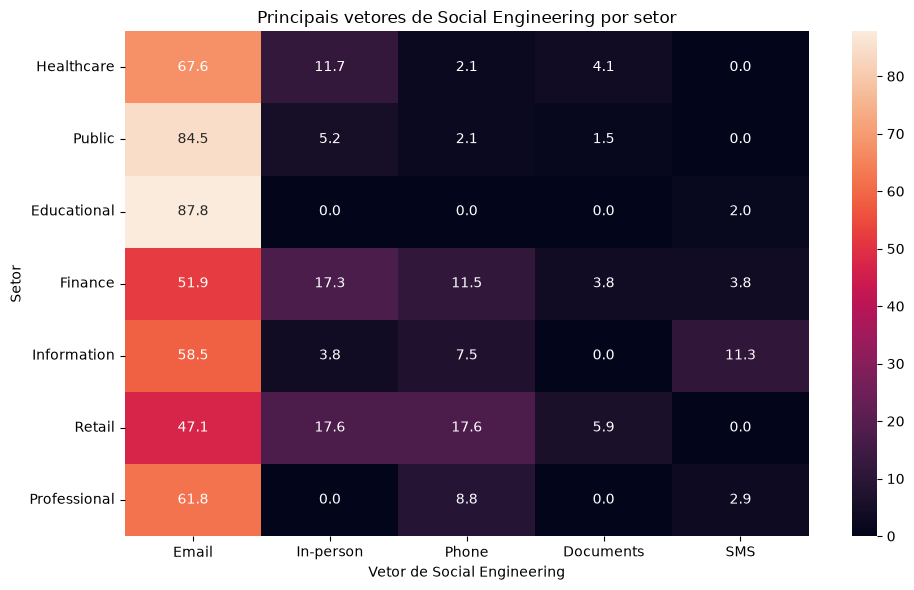

In [41]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabela_principais_social,
    annot=True,
    fmt=".1f"
)

plt.title("Principais vetores de Social Engineering por setor")
plt.xlabel("Vetor de Social Engineering")
plt.ylabel("Setor")

plt.tight_layout()
plt.show()

## 4.7 Error — principais vetores por setor

In [42]:
dados_error = dados[
    dados["action.Error"] == True
]

len(dados_error)

2774

In [43]:
contagem_vetores_error = (
    dados_error[colunas_vetores_error]
    .sum()
    .sort_values(ascending=False)
)

contagem_vetores_error

action.error.vector.Unknown                  1386
action.error.vector.Carelessness             1272
action.error.vector.Inadequate processes       64
action.error.vector.Web application            16
action.error.vector.Random error               15
action.error.vector.Other                      14
action.error.vector.Inadequate technology      11
action.error.vector.Inadequate personnel        6
dtype: int64

In [44]:
tabela_vetores_error = (
    contagem_vetores_error[
        ~contagem_vetores_error.index.str.endswith(".Unknown")
    ]
)

top_vetores_error = (
    tabela_vetores_error
    .head(5)
)

top_vetores_error

action.error.vector.Carelessness            1272
action.error.vector.Inadequate processes      64
action.error.vector.Web application           16
action.error.vector.Random error              15
action.error.vector.Other                     14
dtype: int64

In [45]:
colunas_top_vetores_error = (
    top_vetores_error.index.tolist()
)

tabela_vetores_setor_error = (
    dados_error
    .groupby("victim.industry.name")[colunas_top_vetores_error]
    .mean()
    .mul(100)
    .round(1)
)

In [46]:
tabela_principais_error = (
    tabela_vetores_setor_error
    .loc[setores_principais]
)

tabela_principais_error

,action.error.vector.Carelessness,action.error.vector.Inadequate processes,action.error.vector.Web application,action.error.vector.Random error,action.error.vector.Other
victim.industry.name,,,,,
Healthcare,32.0,1.5,0.1,0.7,0.7
Public,62.3,2.1,0.4,0.1,0.5
Educational,28.3,3.9,0.0,1.3,0.0
Finance,28.6,3.3,0.0,0.0,0.0
Information,46.2,3.0,3.0,0.6,1.2
Retail,40.6,3.1,0.0,3.1,0.0
Professional,55.4,4.5,0.0,1.8,0.9


In [47]:
nomes_vetores_error = {
    "action.error.vector.Carelessness": "Carelessness",
    "action.error.vector.Inadequate processes": "Inadequate processes",
    "action.error.vector.Web application": "Web application",
    "action.error.vector.Random error": "Random error",
    "action.error.vector.Other": "Other"
}

tabela_principais_error = (
    tabela_principais_error
    .rename(columns=nomes_vetores_error)
)

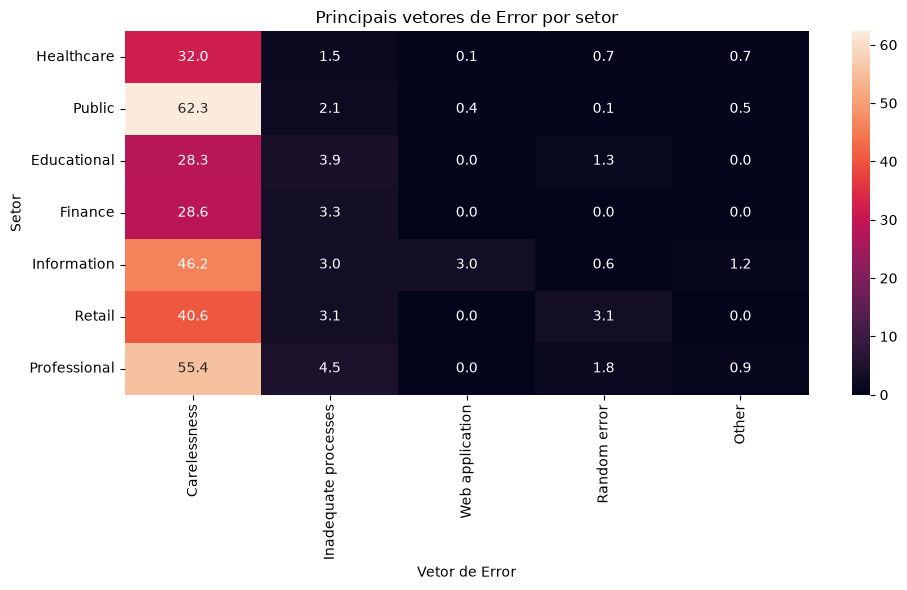

In [48]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    tabela_principais_error,
    annot=True,
    fmt=".1f"
)

plt.title("Principais vetores de Error por setor")
plt.xlabel("Vetor de Error")
plt.ylabel("Setor")

plt.tight_layout()
plt.show()

## 4.8 Principais observações

### Perfil geral

- A base analisada contém 10.596 registros de incidentes de segurança.
- As categorias de ação mais frequentes são Hacking, Error, Misuse, Malware e Physical.
- As categorias de ação podem se sobrepor: um mesmo incidente pode apresentar mais de uma categoria.

### Distribuição por setor

- Healthcare, Public e Educational são os setores com maior quantidade de registros na base analisada.
- Os setores apresentam diferentes distribuições de categorias de ação.

### Hacking

- Web application é o vetor conhecido mais frequente entre os incidentes classificados como Hacking.
- A frequência dos vetores de Hacking varia entre os setores analisados.
- Educational apresenta uma proporção elevada de incidentes de Hacking associados a Web application.

### Malware

- Direct install e Remote injection são os vetores conhecidos mais frequentes entre os incidentes classificados como Malware.
- A distribuição desses vetores varia entre os setores.
- Em Educational e Finance, esses vetores apresentam proporções elevadas dentro dos respectivos incidentes de Malware.

### Social Engineering

- Email é o vetor conhecido mais frequente entre os incidentes classificados como Social Engineering.
- Os demais vetores aparecem em proporções menores e variam entre os setores.

### Error

- Carelessness é o vetor conhecido mais frequente entre os incidentes classificados como Error.
- Uma parcela significativa dos incidentes de Error possui vetor Unknown, limitando a interpretação dessa categoria.

## 4.9 Limitações da análise

### Qualidade e completude dos dados

- A base contém registros com informações não especificadas, representadas principalmente por `Unknown`.
- A presença de `Unknown` é particularmente relevante na análise dos vetores de Error.
- A ausência de informação em determinadas variáveis pode limitar a interpretação dos resultados.

### Sobreposição das categorias

- As categorias de ação não são mutuamente exclusivas.
- Um mesmo incidente pode apresentar mais de uma categoria de ação.
- Os vetores também podem se sobrepor dentro de um mesmo incidente.
- Portanto, os percentuais apresentados não devem ser somados como se representassem partes exclusivas de um total.

### Distribuição dos registros

- A quantidade de registros não é uniforme entre os setores.
- Alguns setores possuem muito mais registros que outros, o que pode influenciar a estabilidade das proporções observadas.
- Setores com poucos registros devem ser interpretados com maior cautela.

### Representatividade

- O VCDB é uma base pública de incidentes e não deve ser interpretado como um levantamento completo de todos os incidentes de segurança existentes.
- A composição dos registros pode refletir critérios de seleção e disponibilidade das informações.
- Portanto, os resultados desta análise descrevem padrões observados na base analisada e não representam necessariamente a distribuição global dos incidentes de segurança.

### Relação entre variáveis

- As análises realizadas são exploratórias e descritivas.
- A associação entre uma categoria de ação, um vetor e um setor não implica relação causal.
- Os resultados indicam padrões presentes nos registros analisados, mas não permitem afirmar que determinada característica causou outra.

## 4.10 Conclusão

A análise exploratória dos 10.596 registros do VCDB permitiu identificar diferentes padrões na distribuição das categorias de ação, setores e vetores associados aos incidentes de segurança.

Hacking e Error aparecem entre as categorias de ação mais frequentes na base analisada. A análise por setor também mostrou diferenças na distribuição dessas categorias, indicando que os registros apresentam perfis distintos entre os setores.

Entre os incidentes classificados como Hacking, Web application foi o vetor conhecido mais frequente. Nos incidentes de Malware, Direct install e Remote
injection apresentaram as maiores frequências entre os vetores conhecidos. Em Social Engineering, Email foi o vetor conhecido mais frequente. ParaError, Carelessness foi o vetor conhecido mais frequente, embora uma parcela relevante dos registros não possua vetor especificado.

Esses resultados descrevem padrões presentes nos registros analisados e não devem ser interpretados como uma representação de todos os incidentes de segurança existentes. A presença de valores Unknown, a sobreposição entre categorias e a composição da base são limitações importantes para a interpretação dos resultados.

O projeto demonstra a aplicação de Python, Pandas, Matplotlib e Seaborn na organização, exploração e visualização de dados de segurança da informação, transformando uma base extensa de registros em análises e visualizações interpretáveis.